### Обзор библиотеки [Gymnasium](https://gymnasium.farama.org/)

In [2]:
# %pip install gymnasium  # базовая часть
# %pip install "gymnasium[classic-control, box2d, other]"  # специальные среды

import gymnasium as gym

### Соответствие теоретических компонент МППР интерфейсу Gymnasium

Любая среда в Gymnasium наследуется от базового класса `gymnasium.Env` и инкапсулирует в себе марковский процесс принятия решений. Взаимодействие агента с экземпляром `env` напрямую отображает теоретические компоненты МППР:

| Компонент МППР | Объект / метод в Gymnasium | Пояснение |
| :--- | :--- | :--- |
| **$\mathcal{S}$** — пространство состояний | `env.observation_space` | Экземпляр класса `Space` |
| **$\mathcal{A}$** — пространство действий | `env.action_space` | Экземпляр класса `Space` |
| **$s_0 \sim \rho_0$** — начальное состояние | `s_0, info = env.reset()` | Сэмплирование из распределения начальных состояний |
| **$\mathcal{P}, \mathcal{R}$** — динамика переходов и наград | `s_next, r, terminated, truncated, info = env.step(a)` | Сэмплирование пары $(s_{t+1}, r_{t+1}) \sim p(\cdot, \cdot \mid s_t, a_t)$ |
| Терминальное состояние | Флаг `terminated`| Булев флаг достижения терминального состояния среды по внутренним правилам МППР |
| Ограничение горизонта | Флаг `truncated` | Булев флаг искусственного прерывания эпизода (таймаут), не связанный с динамикой среды |

### Пространства состояний и действий

Пространства $\mathcal S$ и $\mathcal A$ задаются атрибутами `env.observation_space` и `env.action_space`, являющимися экземплярами подклассов `gymnasium.spaces.Space`. Каждый объект `Space` описывает тип, структуру и допустимые значения элементов соответствующего пространства и предоставляет методы:
- `space.sample()` — равномерный выбор случайного элемента;
- `space.contains(x)` — проверка принадлежности точки пространству.

| Класс пространства | Математическое множество | Применение в МППР |
| :--- | :--- | :--- |
| `Discrete(n)` | Конечное множество $\{0, 1, \ldots, n-1\}$ | Табличные дискретные действия или состояния |
| `Box(low, high, shape)` | Прямое произведение множеств $I_1 \times \ldots \times I_n \subseteq \mathbb{R}^n$, где $I_i$ — отрезок, числовая прямая или луч | Наборы непрерывных состояний или непрерывных управляющих сигналов |
| `MultiDiscrete([n_1, ..., n_k])` | Прямое произведение $\{0, \ldots, n_1-1\} \times \ldots \times \{0, \ldots, n_k-1\}$ | Наборы дискретных состояний или дискретных управляющих сигналов |
| `Dict({key: Space})` | Прямое произведение разнородных пространств | Сложные составные состояния или управления (например, кортеж информации от датчиков и матриц изображений) |

### Среда CartPole-v1

Среда `CartPole-v1` моделирует классическую задачу балансировки шеста на подвижной тележке:

 - Пространство состояний $\mathcal{S} \subset \mathbb{R}^4$. Состояние задается набором $s = (x, \dot{x}, \theta, \dot{\theta})$, где $x$ — положение тележки, $\dot x$ — её скорость, $\theta$ — угол отклонения шеста от вертикали, $\dot \theta$ — угловая скорость шеста.
 - Пространство действий $\mathcal{A} = \{0, 1\}$. Бинарный выбор перемещения тележки — перемещение влево ($a = 0$) или вправо ($a = 1$).
 - Функция наград $\mathcal{R}(s, a)$. Награда  $+1$ за каждый такт времени, пока шест остаётся в допустимом диапазоне.
 - Условия остановки. Эпизод завершается, если шест падает ($|\theta| > 12^\circ$) или тележка выходит за пределы поля ($|x| > 2.4$); эпизод принудительно прерывается при достижении лимита $T = 500$ шагов.

In [7]:
# Пример инспекции размерностей и типов пространств

env = gym.make("CartPole-v1")

# Пространство состояний S: неограниченный четырёхмерный прямоугольный параллелепипед
print('env.observation_space:', env.observation_space)

# Пространство действий A: множество из 2 элементов {0, 1}
print('env.action_space:', env.action_space)

# Сэмплирование случайного действия
print('env.action_space.sample():', env.action_space.sample())

env.observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
env.action_space: Discrete(2)
env.action_space.sample(): 1


In [8]:
import time

# Простая эвристическая стратегия: если шест падает вправо, толкаем тележку вправо (a = 1), иначе — влево (a = 0)
def dummy_policy(state):
    x, x_dot, theta, theta_dot = state
    return 1 if theta > 0 else 0

# Режим "human" автоматически отрисовывает окно при каждом step()
env = gym.make("CartPole-v1", render_mode="human")
s, info = env.reset(seed=42)

# Цикл генерации траектории: tau = (s_0, a_0, r_1, s_1, ...)
for _ in range(200):
    a = dummy_policy(s)
    s, r, terminated, truncated, info = env.step(a)  # Шаг среды: (s_{t+1}, r_{t+1}) ~ p(\cdot, \cdot | s_t, a_t)
    
    time.sleep(0.05)
    
    if terminated or truncated:
        s, info = env.reset()

env.close()

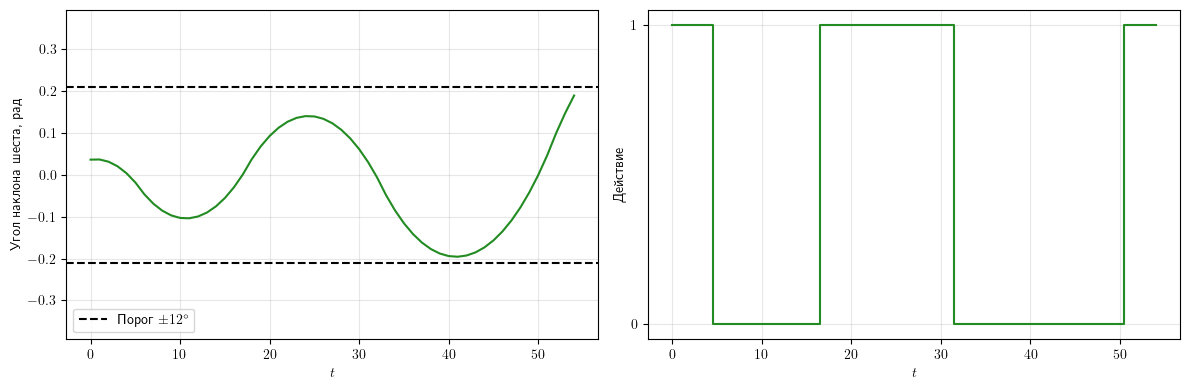

In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage[utf8]{inputenc}\usepackage[T2A]{fontenc}\usepackage[russian]{babel}',
})

env = gym.make("CartPole-v1")
s, info = env.reset(seed=42)

thetas, actions = [], []

for _ in range(200):
    thetas.append(s[2])       # Угол \theta
    a = dummy_policy(s)       # Действие a = \mu(s)
    actions.append(a)
    
    s, r, terminated, truncated, info = env.step(a)

    if terminated or truncated:
        break

env.close()

# Терминальный порог угла наклона шеста в CartPole 12 градусов
theta_limit = 12 * 2 * np.pi / 360

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thetas, color='forestgreen')
axes[0].axhline(theta_limit, color='black', ls='--', label=r'Порог $\pm 12^\circ$')
axes[0].axhline(-theta_limit, color='black', ls='--')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel(r'Угол наклона шеста, рад')
axes[0].set_ylim([-np.pi / 8, np.pi / 8])
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='lower left')

axes[1].step(range(len(actions)), actions, color='forestgreen', where='mid')
axes[1].set_yticks([0, 1])
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('Действие')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

### Обёртки среды (Wrappers)

Обёртка $W$ осуществляет отображение базового МППР $\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R} \rangle$ в модифицированный процесс $\mathcal{M}' = \langle \mathcal{S}', \mathcal{A}', \mathcal{P}', \mathcal{R}' \rangle$, переопределяя фазовые пространства `observation_space`, `action_space` или методы динамики `step`, `reset` и `render`.

По умолчанию «чистая» среда симулирует реальные физические законы и возвращает физические величины (метры, радианы, вольты). Однако для эффективного обучения нейросетей данные часто требуют специфической предобработки (нормализации, фильтрации, объединения кадров). Обёртки позволяют изолировать эту логику от самого алгоритма RL.

При создании среды вызовом `gym.make("CartPole-v1")` Gymnasium автоматически накладывает три базовых служебных декоратора:
```text
<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPole-v1>>>>
```

- **`PassiveEnvChecker`** — автоматически валидирует типы данных при отладке: следит, чтобы состояния и действия строго лежали в пределах заявленных пространств $\mathcal{S}$ и $\mathcal{A}$, а награды являлись конечными вещественными числами (не `NaN` и не $\pm\infty$).
- **`OrderEnforcing`** — контролирует протокол взаимодействия: блокирует вызов `step()` до первичной инициализации состояния $s_0 \sim \rho_0$ через метод `reset()`.
- **`TimeLimit(max_episode_steps)`** — формирует внешнее ограничение горизонта $T$, выставляя флаг `truncated = True` при достижении лимита шагов. Это предотвращает бесконечное зацикливание агента в средах без естественных терминальных состояний.

| Категория | Класс обёртки | Назначение и математический смысл преобразования |
| :--- | :--- | :--- |
| Обработка визуальных состояний | `GrayscaleObservation` | Проецирует RGB-тензор $(H, W, 3)$ в матрицу яркости $(H, W, 1)$, снижая размерность входа в 3 раза. |
| | `ResizeObservation(shape)` | Масштабирует пространственное разрешение кадра (например, до $84 \times 84$). |
| | `FrameStackObservation(k)` | Объединяет $k$ последовательных кадров в стек: $\hat s_t = (s_t, s_{t-1}, \ldots, s_{t-k+1})$. Восстанавливает марковское свойство в частично наблюдаемых средах. |
| Стабилизация градиентных методов | `NormalizeObservation` | Центрирует и масштабирует состояние: $\hat{s}_t = (s_t - \mu_t)/\sqrt{\sigma_t^2 + \varepsilon}$ на основе скользящих статистик. Устраняет разницу масштабов компонент столбца состояний. |
| | `NormalizeReward` | Масштабирует награды: $\hat{r}_{t+1} = r_{t+1} / \sqrt{\sigma_R^2 + \varepsilon}$, обеспечивая устойчивость градиентного спуска независимо от исходного масштаба целевого функционала среды. |
| | `RescaleAction(min, max)` | Линейно отображает столбец действий из стандартного диапазона выходов нейросети $[-1, 1]^m$ в физический рабочий диапазон приводов $[a_{\min, 1}, a_{\max, 1}] \times \ldots \times [a_{\min, m}, a_{\max, m}]$. |
| Мониторинг и логирование | `RecordEpisodeStatistics` | Автоматически вычисляет длительность каждого завершённого эпизода $T$ и суммарную недисконтированную отдачу $G = \sum\limits_{t=1}^T R_t$, добавляя их в словарь `info` для построения графиков обучения. |
| | `RecordVideo` | Сохраняет видеозаписи взаимодействия агента со средой с заданным интервалом эпизодов. |

Обёртки применяются последовательно изнутри наружу (как математическая композиция функций $W_2(W_1(\mathcal{M}))$), поэтому их порядок не всегда коммутативен.  Например, вызов `FrameStackObservation(ResizeObservation(env, 84), stack_size=4)` сначала масштабирует один 2D-кадр до размера $84 \times 84$, а затем склеивает кадры в стек. Обратный порядок приведёт к ошибке, так как `ResizeObservation` не рассчитан на работу с 4-мерными тензорами уже сформированного стека.

Каждая обёртка хранит ссылку на вложенную среду `self.env` и прозрачно делегирует ей все непереопределённые вызовы. Если внешние декораторы скрывают необходимые низкоуровневые параметры или методы базового процесса, прямой доступ к исходной среде осуществляется через атрибут `unwrapped`.

In [6]:
from gymnasium.wrappers import RecordEpisodeStatistics

env = gym.make("CartPole-v1")
env = RecordEpisodeStatistics(env)  # Обёртка сбора статистики

print("Цепочка обёрток среды:")
print(env)  # <RecordEpisodeStatistics<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPole-v1>>>>>

s, info = env.reset(seed=42)

for t in range(500):
    a = env.action_space.sample()
    s, r, terminated, truncated, info = env.step(a)
    
    if terminated or truncated:
        print("\n--- Эпизод завершён ---")
        print(f"Шагов до падения шеста: {t + 1}")
        # Статистика из словаря info, собранная RecordEpisodeStatistics:
        print(f"Полная недисконтированная награда G_0: {float(info['episode']['r']):.1f}")
        print(f"Зафиксированная длина эпизода l:       {int(info['episode']['l'])}")
        print(f"Время выполнения эпизода t:            {float(info['episode']['t']):.4f} сек")
        break

base_env = env.unwrapped
print("\n--- Доступ через env.unwrapped ---")
print(f"Тип исходного базового класса:                     {type(base_env)}")
print(f"Внутреннее состояние (x, x_dot, theta, theta_dot): {base_env.state}")
print(f"Физическая масса шеста в симуляторе:               {base_env.masspole} кг")

Цепочка обёрток среды:
<RecordEpisodeStatistics<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>>

--- Эпизод завершён ---
Шагов до падения шеста: 34
Полная недисконтированная награда G_0: 34.0
Зафиксированная длина эпизода l:       34
Время выполнения эпизода t:            0.0024 сек

--- Доступ через env.unwrapped ---
Тип исходного базового класса:                     <class 'gymnasium.envs.classic_control.cartpole.CartPoleEnv'>
Внутреннее состояние (x, x_dot, theta, theta_dot): [ 0.33013075  1.1534744  -0.22333879 -1.52373928]
Физическая масса шеста в симуляторе:               0.1 кг


In [20]:
from gymnasium.wrappers import GrayscaleObservation, ResizeObservation, FrameStackObservation

env = gym.make("CarRacing-v3")
print(f"Исходное пространство состояний (RGB): {env.observation_space.shape}")

env = GrayscaleObservation(env)  # R^{H x W x 3} -> R^{H x W x 1}
print(f"После GrayscaleObservation:            {env.observation_space.shape}")

env = ResizeObservation(env, shape=(84, 84))  # R^{H x W x 1} -> R^{84 x 84 x 1}
print(f"После ResizeObservation (84x84):       {env.observation_space.shape}")

env = FrameStackObservation(env, stack_size=4)  # Расширение пространства состояний: (4, 84, 84)
print(f"Итоговый стек кадров (k=4):            {env.observation_space.shape}")

s_0, _ = env.reset()
print(f"Размеры массива s_0:                   {s_0.shape}")

env.close()

Исходное пространство состояний (RGB): (96, 96, 3)
После GrayscaleObservation:            (96, 96)
После ResizeObservation (84x84):       (84, 84)
Итоговый стек кадров (k=4):            (4, 84, 84)
Размеры массива s_0:                   (4, 84, 84)


### Векторизованные среды

Для повышения вычислительной эффективности современные методы обучения с подкреплением осуществляют сбор траекторий одновременно из $N$ независимых копий одного и того же МППР. Gymnasium предоставляет интерфейс **векторизованных сред** через функцию `gym.make_vec`, объединяющую $N$ копий процесса в единый параллельный поток с пакетной обработкой (батчингом) данных. Режимы векторного исполнения:
- `"sync"` (`SyncVectorEnv`) — выполнение шагов происходит последовательно в основном процессе. Ускорение достигается за счёт векторизации последующих матричных операций в нейросетевых моделях на GPU.
- `"async"` (`AsyncVectorEnv`) — каждый экземпляр среды изолирован в отдельном системном процессе. Обеспечивает параллельный сбор переходов на многоядерных CPU.

In [7]:
# Создание N=4 параллельных экземпляров МППР CartPole

num_envs = 4
envs = gym.make_vec("CartPole-v1", num_envs=num_envs, vectorization_mode="async")

print(f"Базовое пространство состояний одного МППР: {envs.single_observation_space.shape}")
print(f"Векторизованное пространство состояний:     {envs.observation_space.shape}")
print(f"Векторизованное пространство действий:      {envs.action_space}\n")

# Генерация пакета начальных состояний: s_0 \in \mathcal{S}^4
s_batch, infos = envs.reset(seed=42)
print(f"Пакет начальных состояний s_0:")
print(s_batch)

# Генерация пакета действий: a \in \mathcal{A}^4
a_batch = envs.action_space.sample()
print(f"\nСгенерированный пакет действий: {a_batch}")

# Параллельный такт взаимодействия
s_next_batch, r_batch, term_batch, trunc_batch, infos = envs.step(a_batch)

print(f"\nПакет следующих состояний s_1:")
print(s_next_batch)
print(f"\nПакет немедленных наград r_1: {r_batch}")
print(f"Маска терминальных состояний:   {term_batch}")
print(f"Маска искусственных таймаутов:  {trunc_batch}")

envs.close()

Базовое пространство состояний одного МППР: (4,)
Векторизованное пространство состояний:     (4, 4)
Векторизованное пространство действий:      MultiDiscrete([2 2 2 2])

Пакет начальных состояний s_0:
[[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
 [ 0.01522993 -0.04562247 -0.04799704  0.03392126]
 [-0.03774345 -0.02418869 -0.00942293  0.0469184 ]
 [ 0.00731307  0.00284911  0.02636502  0.03116928]]

Сгенерированный пакет действий: [0 0 1 0]

Пакет следующих состояний s_1:
[[ 0.02727336 -0.20172954  0.03625453  0.32351476]
 [ 0.01431748 -0.24002443 -0.04731862  0.3110827 ]
 [-0.03822722  0.1710671  -0.00848456 -0.2487226 ]
 [ 0.00737005 -0.19264081  0.02698841  0.33205268]]

Пакет немедленных наград r_1: [1. 1. 1. 1.]
Маска терминальных состояний:   [False False False False]
Маска искусственных таймаутов:  [False False False False]


### Создание пользовательской среды

Для программной спецификации произвольного МППР создаётся класс-наследник `gymnasium.Env`. Интерфейс требует определения базовых компонентов:

1. `__init__(self)` — определение пространств состояний $\mathcal{S}$ (`observation_space`) и действий $\mathcal{A}$ (`action_space`).
2. `reset(self, seed, options)` — моделирование начального распределения $s_0 \sim \rho_0$.
3. `step(self, action)` — генерация перехода $(s_{t+1}, r_{t+1}) \sim p(\cdot, \cdot \mid s_t, a_t)$ и проверка условия завершения эпизода $s_{t+1} \in \mathcal{S}_{\mathrm{term}}$.

Пользовательская табличная среда GridWorld $3 \times 3$

- $\mathcal{S} = \{0, 1, \ldots, 8\}$ — девять клеток координатной сетки $3 \times 3$; начальное состояние фиксировано: $s_0 = (0, 0)$, что соответствует индексу $0$.
- $\mathcal{A} = \{0, 1, 2, 3\}$ — четыре варианты выбора действий: $\{0: \uparrow, 1: \downarrow, 2: \leftarrow, 3: \rightarrow\}$. Действия, направленные за границу сетки, не изменяют состояние среды ($s' = s$).
- $\mathcal{S}_{\text{term}} = \{8\}$, что соответствует клетке $(2, 2)$. Эта клетка является целевым состоянием.
- Функция наград: $\mathcal{R}(s, a, s') = +1.0$, если $s' \in \mathcal{S}_{\mathrm{term}}$, и $-0.04$ для всех остальных нетерминальных переходов.


In [10]:
from gymnasium import spaces
import numpy as np

class GridWorld3x3(gym.Env):
    """Пользовательская среда: детерминированный табличный МППР GridWorld 3x3."""

    def __init__(self):
        # обращение к родительскому классу gymnasium.Env
        super().__init__()
        # |A| = 4
        self.action_space = spaces.Discrete(4)
        # |S| = 9
        self.observation_space = spaces.Discrete(9)
  
        self.agent_pos = np.array([0, 0], dtype=np.int32)
        self.goal_pos = np.array([2, 2], dtype=np.int32)

    def reset(self, seed=None, options=None):
        # Инициализация встроенного генератора псевдослучайных чисел для обеспечения воспроизводимости
        super().reset(seed=seed)
        # Инициализация начального состояния s_0
        self.agent_pos = np.array([0, 0], dtype=np.int32)
        return self._get_obs(), {}

    def step(self, action):
        # Функция переходов среды \mathcal{P}
        moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        delta = np.array(moves[action], dtype=np.int32)
  
        # Ограничение пределами сетки
        self.agent_pos = np.clip(self.agent_pos + delta, 0, 2)

        # Проверка достижения терминального множества
        terminated = bool(np.array_equal(self.agent_pos, self.goal_pos))

        # Функция наград \mathcal{R}
        reward = 1.0 if terminated else -0.04

        return self._get_obs(), float(reward), terminated, False, {}

    def _get_obs(self):
        # Биективное отображение координат (i, j) \in {0,1,2}^2 в номер состояния s \in {0..8}
        return int(self.agent_pos[0] * 3 + self.agent_pos[1])

gym.register(
    id="GridWorld3x3-v0",
    entry_point="__main__:GridWorld3x3",
    max_episode_steps=50,  # автоматическое наложение обёртки TimeLimit
    )

env = gym.make("GridWorld3x3-v0")

C:\Users\avsakharov\miniforge3\envs\rl\lib\site-packages\gymnasium\envs\registration.py:637: UserWarning: WARN: Overriding environment GridWorld3x3-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [11]:
s, info = env.reset(seed=42)
print("s_0:", s)

a = 1
s, r, terminated, truncated, info = env.step(a)
print("s_1, r_1, terminated, truncated, info:", s, r, terminated, truncated, info)

s_0: 0
s_1, r_1, terminated, truncated, info: 3 -0.04 False False {}


### Стандартные семейства сред Gymnasium

Коллекция сред Gymnasium разбита на семейства в зависимости от размерности и математической структуры пространств $\mathcal{S}$ и $\mathcal{A}$:

| Семейство сред | Пространство состояний $\mathcal{S}$ | Пространство действий $\mathcal{A}$ | Применение в теории и практике RL |
| :--- | :--- | :--- | :--- |
| **Toy Text** | Конечное множество (`Discrete`) | Конечное множество (`Discrete`) | Табличные методы динамического программирования, аналитическое решение уравнений Беллмана, базовые алгоритмы TD-обучения ($Q$-learning, SARSA). |
| **Classic Control** | Непрерывный вектор (`Box` в $\mathbb{R}^n$) | Дискретное (`Discrete`) или скалярное (`Box`) | Классические задачи динамической стабилизации (CartPole, Pendulum, MountainCar); отладка алгоритмов линейной и нейросетевой аппроксимации функций ценности. |
| **Box2D** | Непрерывный вектор / матрица | Дискретное или непрерывное (`Box`) | Задачи плоской физики твёрдого тела со сложными контактами (LunarLander, BipedalWalker); тестирование градиентных методов оптимизации стратегий. |
| **MuJoCo** | Непрерывный фазовый вектор ($\mathbb{R}^n$, $n \gg 1$) | Непрерывный вектор управляющих моментов (`Box`) | Многозвенные биомеханические системы с кинематическими связями (HalfCheetah, Ant, Humanoid); стандартные бенчмарки для задач непрерывного управления (DDPG, TD3, SAC, PPO). |
| **Atari (ALE)** | Тензор пикселей изображения | Конечное множество (`Discrete`) | Задачи управления в условиях высокой размерности входов; полигон глубокого обучения с подкреплением на основе свёрточных сетей (DQN, Rainbow). |

### Экосистема [Farama Foundation](https://farama.org/)

1. **Базовые проекты (Core Projects).** Фундаментальные библиотеки, задающие архитектурные стандарты взаимодействия агентов со средами:
   - **Gymnasium** — центральная библиотека API для одиночных марковских процессов принятия решений (Single-Agent MDP).
   - **PettingZoo** — прямой аналог Gymnasium для **многоагентных систем** (Multi-Agent RL, MARL).
   - **Minari** — стандарт и хранилище датасетов для **офлайн-обучения с подкреплением** (Offline RL / Batch RL). Преемник D4RL (Datasets for Deep Data-Driven Reinforcement Learning), позволяющий скачивать и логировать статические датасеты траекторий $\tau$.

2. **Зрелые прикладные библиотеки сред (Mature Projects).** Специализированные пакеты сред, полностью совместимые с API Gymnasium:
    - **Робототехника и непрерывное управление:**
	    - **Gymnasium-Robotics** — задачи манипуляции и навигации манипуляторов.
	    - **Metaworld** — бенчмарк для мета-обучения и Multi-Task RL.
	    - **MOMAland** — многоцелевая робототехника с мобильными манипуляторами.
    - **Сетки и дискретное планирование:**
	    - **Minigrid** — легковесные и быстрые двумерные сеточные миры (GridWorld).
	- **Многокритериальная оптимизация:**
		  - **MO-Gymnasium (Multi-Objective)** — среды с векторной функцией наград со значениями в $\mathcal U_R \subseteq \mathbb{R}^k$, где $k>1$. Парето-оптимальность решений.
	- **Многоагентные задачи:**
		  - **MPE2 (Multi-Particle Environments)** — классические частичные 2D-миры.
		  - **MAgent2** — масштабируемые симуляции с тысячами одновременно взаимодействующих агентов.
	- **Видеоигры и сложные 3D-симуляторы:**
		  - **ViZDoom** — 3D-шутер от первого лица с визуальным входом.
		  - **Stable-Retro** — поддержка тысяч ретро-игр для приставок (NES, SNES, Sega Genesis, Game Boy).
		  - **Shimmy** — библиотека-адаптер (мост), позволяющая запускать сторонние среды (DM Control Suite, PyBullet, OpenSpiel) через стандартный интерфейс Gymnasium.
  
3. **Инкубационные проекты (Incubating Projects).** Новые или переносимые под эгиду Farama библиотеки:
	  - **Arcade Learning Environment (ALE)** — официальный бэкенд для запуска игр Atari 2600.
	  - **HighwayEnv** — среда симуляции дорожного движения и автономного вождения.
	  - **Procgen2** — процедурно-генерируемые 2D-игры для исследования обобщающей способности RL-агентов.